<a href="https://colab.research.google.com/github/sanganalasya-hash/Data-Science/blob/main/AP_Research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import arviz as az
import pymc as pm
import graphviz as gv
import matplotlib.pyplot as plt
import seaborn as sns
import bambi as bmb

In [ ]:
!pip install bambi

In [ ]:
!pip install --upgrade xarray

# Part A

In [ ]:
econ = pd.read_csv('https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/hemline_economy_clean_main.csv')

In [ ]:
econ

In [ ]:
sns.pairplot(econ)

In [ ]:
dag_econ = gv.Digraph(comment='bballh_dag') #bball hierarchy

dag_econ.node('H', 'Hemline')
dag_econ.node('Y','Year')
dag_econ.node('C','CCI')
dag_econ.node('U','Unemployment')
dag_econ.node('I','Income')

dag_econ.edges(['CH','UH', 'IH',  'UC', 'IC', 'UI'])

dag_econ

## Model 1

In [ ]:
#define the model
model_1 = bmb.Model("`Hemline` ~ `CCI` + `Year`", data=econ, family="t")
#fit the model, generating posterior predictive samples directly
idata_1 = model_1.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_1 = model_1.predict(idata_1, kind='response')

In [ ]:
az.plot_ppc(idata_1, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 2

In [ ]:
#define the model
model_2 = bmb.Model("`Hemline` ~ `Unemployment` + `Year`", data=econ, family="t")
#fit the model
idata_2 = model_2.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_2 = model_2.predict(idata_2, kind='response')

In [ ]:
az.plot_ppc(idata_2, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 3

In [ ]:
#define the model
model_3 = bmb.Model("`Hemline` ~ `Unemployment` + `CCI` + `Year`", data=econ, family="t")
#fit the model
idata_3 = model_3.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_3 = model_3.predict(idata_3, kind='response')

In [ ]:
az.plot_ppc(idata_3, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 4

In [ ]:
model_4 = bmb.Model("Hemline ~ CCI + Unemployment + CCI:Unemployment + Year", data=econ, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4 = model_4.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

In [ ]:
pp_idata_4 = model_4.predict(idata_4, kind='response')

In [ ]:
az.plot_ppc(idata_4, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 5

In [ ]:
model_5 = bmb.Model("Hemline ~ CCI + Unemployment + CCI|Unemployment + Year", data=econ, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Compare A

In [ ]:
cmp_df = az.compare({
    'CCI + Year': idata_1,
    'Unemployment + Year': idata_2,
    'CCI + Unemployment + Year': idata_3,
    'CCI + Unemployment + Year + CCI:Unemployment': idata_4,
    'CCI + Unemployment + Year + CCI|Unemployment': idata_5,
})

display(cmp_df)

In [ ]:
az.plot_compare(cmp_df)

# Part B

In [ ]:
econ_1 = pd.read_csv('https://raw.githubusercontent.com/sanganalasya-hash/Data-Science/refs/heads/main/hemline_economy_clean_with_income.csv')

In [ ]:
econ_1

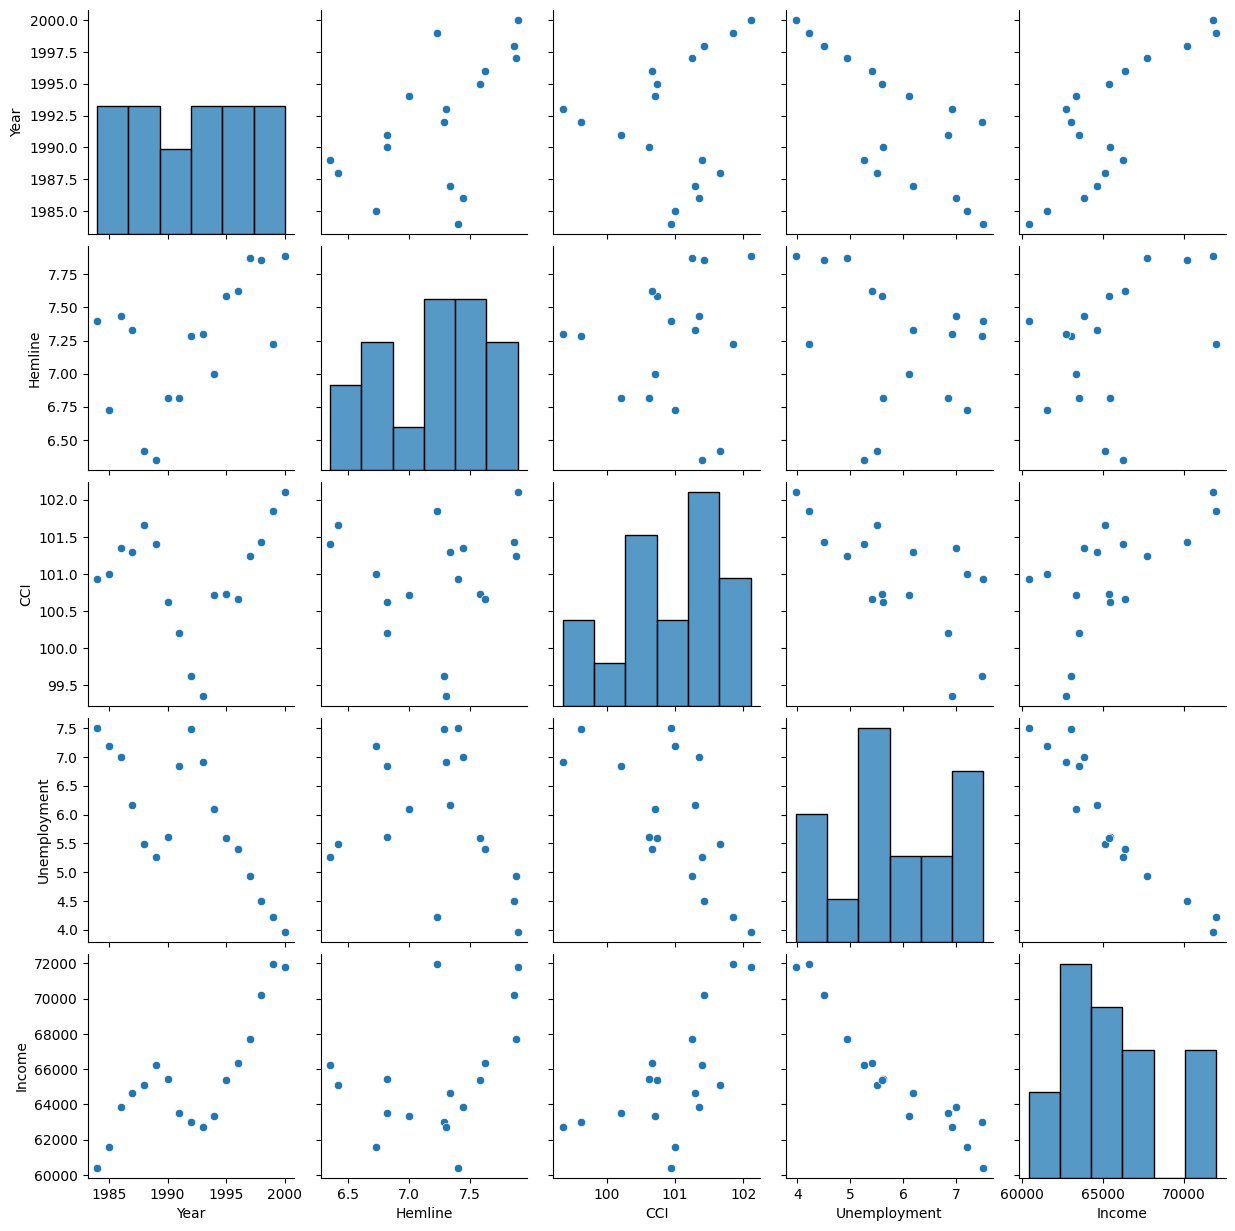

In [44]:
sns.pairplot(econ_1)

## Model 1b

In [ ]:
#define the model
model_1b = bmb.Model("`Hemline` ~ `CCI` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_1b = model_1b.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_1b = model_1b.predict(idata_1b, kind='response')

In [ ]:
az.plot_ppc(idata_1b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 2b

In [ ]:
#define the model
model_2b = bmb.Model("`Hemline` ~ `Unemployment` + `Year`", data=econ_1, family="t")
#fit the model
idata_2b = model_2b.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_2b = model_2b.predict(idata_2b, kind='response')

In [ ]:
az.plot_ppc(idata_2b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 3b

In [ ]:
#define the model
model_3b = bmb.Model("`Hemline` ~ `Unemployment` + `CCI` + `Year`", data=econ_1, family="t")
#fit the model
idata_3b = model_3b.fit(idata_kwargs={'log_likelihood': True})

In [ ]:
pp_idata_3b = model_3b.predict(idata_3b, kind='response')

In [ ]:
az.plot_ppc(idata_3b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 4b

In [ ]:
#define the model using the new interaction term
model_4b = bmb.Model("Hemline ~ CCI + Unemployment + CCI:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4b = model_4b.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

In [ ]:
pp_idata_4b = model_4b.predict(idata_4b, kind='response')

In [ ]:
az.plot_ppc(idata_4b, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 5

In [ ]:
#define the model
model_5 = bmb.Model("`Hemline` ~ `Unemployment` + `Income` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_5 = model_5.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_5 = model_5.predict(idata_5, kind='response')

In [ ]:
az.plot_ppc(idata_5, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 6

In [ ]:
#define the model
model_6 = bmb.Model("`Hemline` ~ `Income` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_6 = model_6.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_6 = model_6.predict(idata_6, kind='response')

In [ ]:
az.plot_ppc(idata_6, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 7

In [ ]:
#define the model
model_7 = bmb.Model("`Hemline` ~ `Unemployment` + `Income` + `CCI` + `Year`", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_7 = model_7.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_7 = model_7.predict(idata_7, kind='response')

In [ ]:
az.plot_ppc(idata_7, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 8


In [ ]:
#define the model
model_8 = bmb.Model("Hemline ~ Income + Unemployment + Income:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_8 = model_8.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

In [ ]:
pp_idata_8 = model_8.predict(idata_8, kind='response')

In [ ]:
az.plot_ppc(idata_8, num_pp_samples=100, figsize=(12, 4), colors=["C1", "C0", "C1"])

## Model 9

In [ ]:
#define the model
model_9 = bmb.Model("Hemline ~ CCI + Unemployment:Income + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_9 = model_9.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 10


In [ ]:
#define the model
model_10 = bmb.Model("Hemline ~ Income:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_10 = model_10.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 11

In [ ]:
#define the model
model_11 = bmb.Model("Hemline ~ CCI:Unemployment + Year", data=econ_1, family="t")
#fit the model, generating posterior predictive samples directly
idata_11 = model_11.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Compare B

In [ ]:
cmp_df_1 = az.compare({
       'CCI': idata_1b,
    'Unemployment + Year': idata_2b,
    'CCI + Unemployment + Year': idata_3b,
    'CCI + Unemployment + Year + CCI:Unemployment': idata_4b,
    'Income + Unemployment + Year': idata_5,
    'Income + Year': idata_6,
    'CCI + Unemployment + Income + Year': idata_7,
    'Income + Unemployment + Year + Income:Unemployment': idata_8,
    'CCI + Unemployment:Income + Year': idata_9,
    'Income:Unemployment + Year': idata_10,
  'CCI:Unemployment + Year': idata_11
})

display(cmp_df_1)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

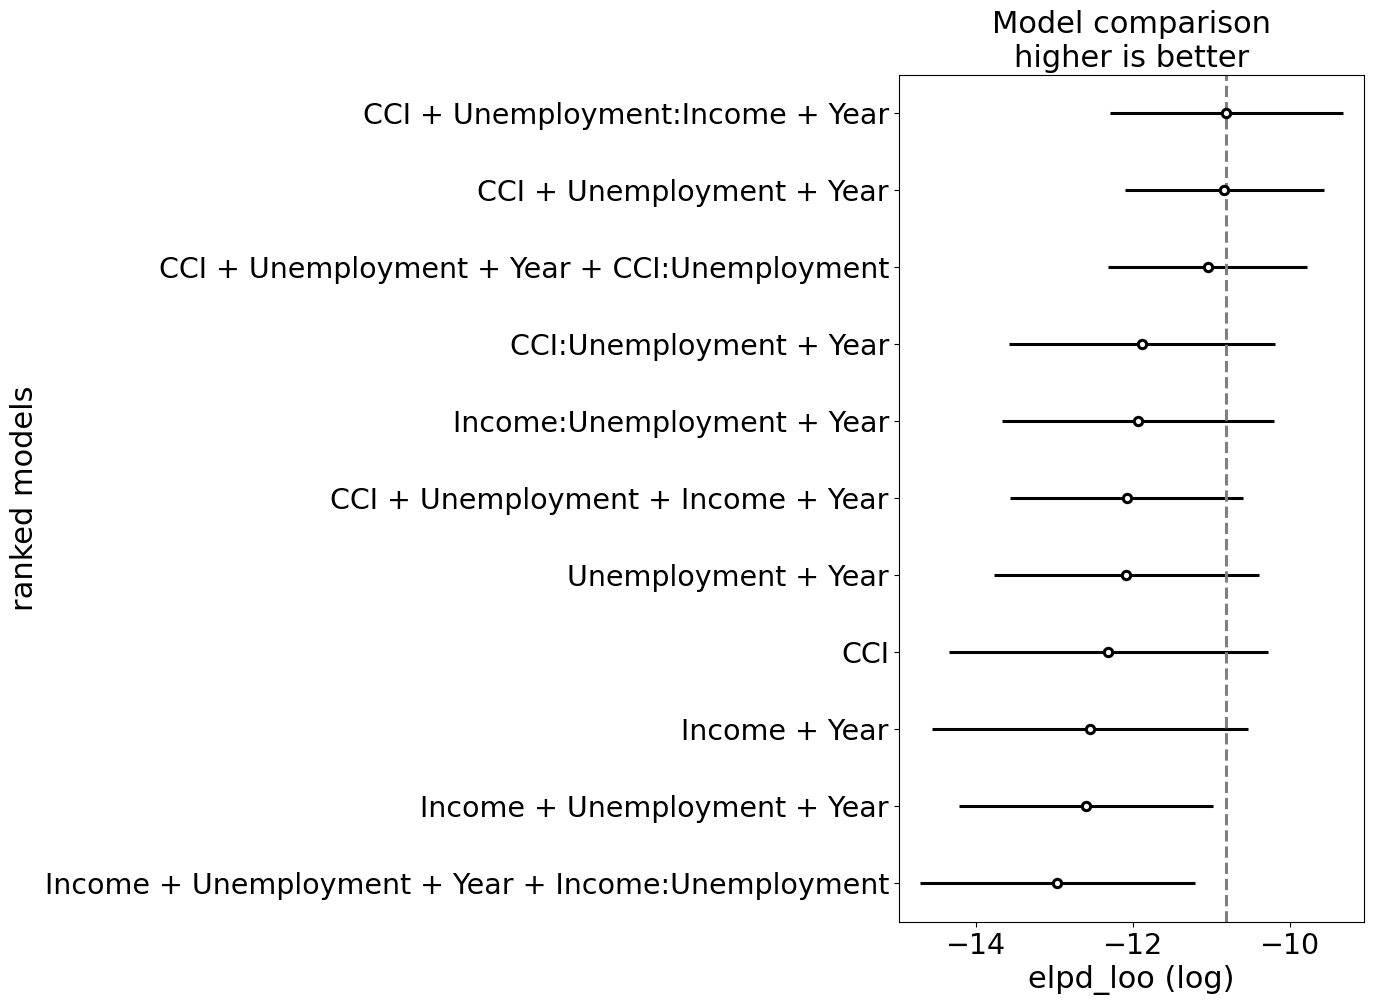

In [42]:
az.plot_compare(cmp_df_1)

# Part C

In [ ]:
econ_1_lag = econ_1.copy()

econ_1_lag["CCI"] = econ_1_lag["CCI"].shift(3)
econ_1_lag["Unemployment"] = econ_1_lag["Unemployment"].shift(3)

econ_1_lag = econ_1_lag.dropna().copy()

In [ ]:
econ_1_lag

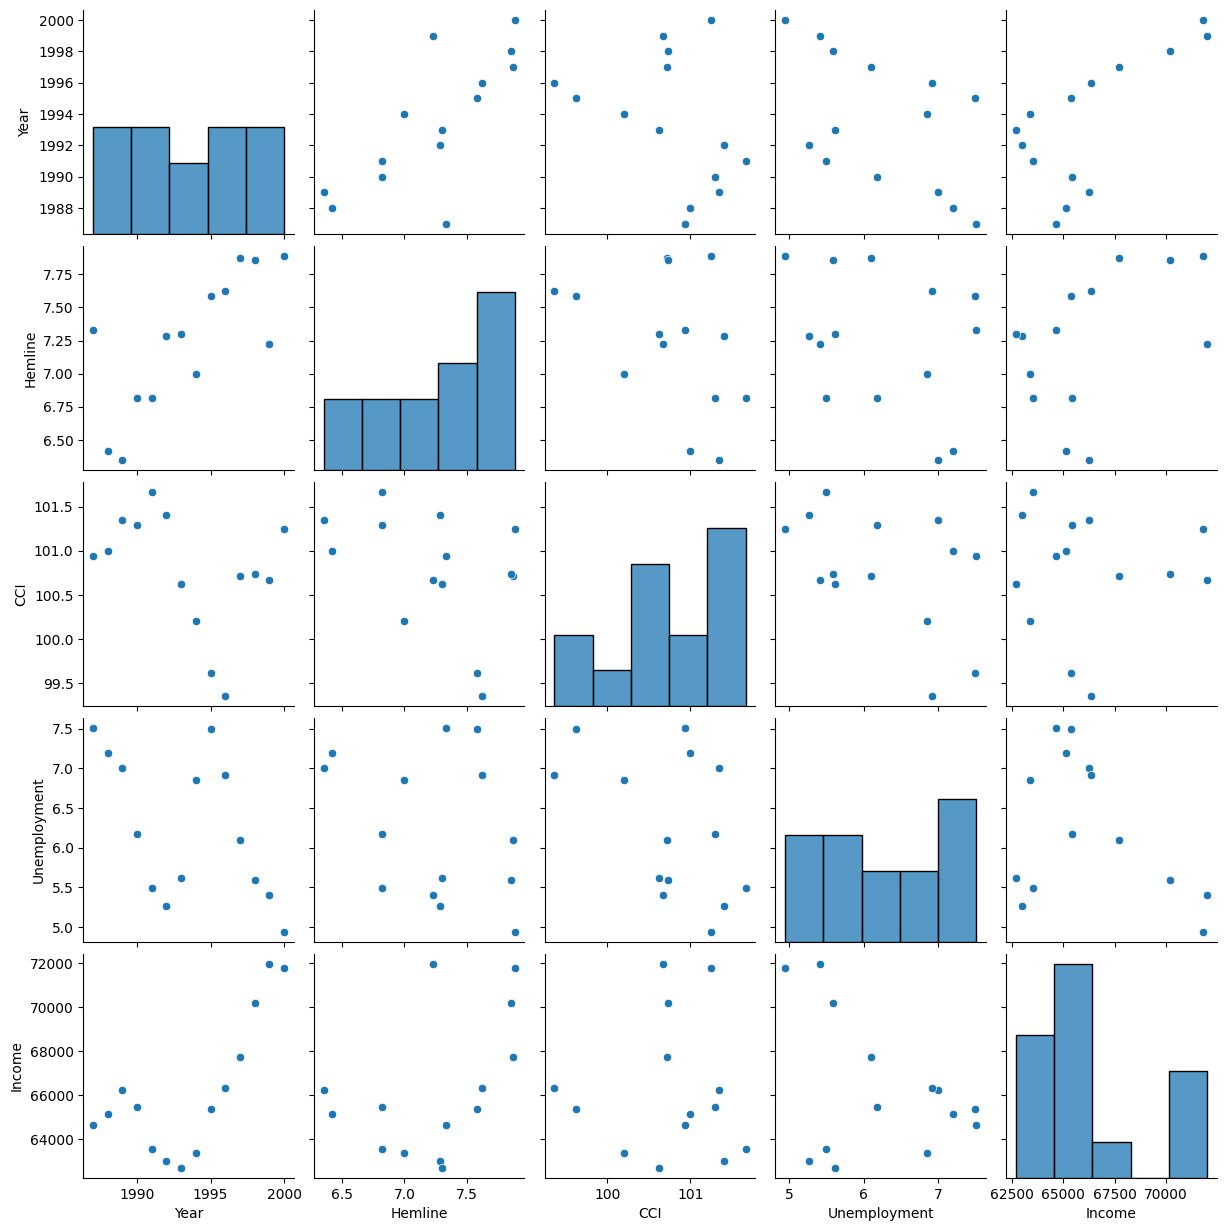

In [43]:
sns.pairplot(econ_1_lag)

## Model 1c

In [ ]:
#define the model
model_1c = bmb.Model("`Hemline` ~ CCI + Unemployment:Income + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly
idata_1c = model_1c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True)

## Model 2c

In [ ]:
#define the model
model_2c = bmb.Model("`Hemline` ~ CCI + Unemployment + Year", data=econ_1_lag, family="t")
#fit the model
idata_2c = model_2c.fit(idata_kwargs={'log_likelihood': True})

## Model 3c

In [ ]:
#define the model
model_3c = bmb.Model("`Hemline` ~ Income:Unemployment + Year", data=econ_1_lag, family="t")
#fit the model
idata_3c = model_3c.fit(idata_kwargs={'log_likelihood': True})

## Model 4c

In [ ]:
model_4c = bmb.Model("Hemline ~ CCI:Unemployment + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_4c = model_4c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Model 5c

In [ ]:
model_5c = bmb.Model("Hemline ~ CCI + Year", data=econ_1_lag, family="t")
#fit the model, generating posterior predictive samples directly, increasing target_accept to mitigate divergences
idata_5c = model_5c.fit(idata_kwargs={'log_likelihood': True}, posterior_predictive=True, nuts_args={'target_accept': 0.95})

## Compare C

In [ ]:
cmp_df_c = az.compare({
    'CCI + Unemployment:Income + Year': idata_1c,
    'CCI + Unemployment + Year': idata_2c,
    'Income:Unemployment + Year': idata_3c,
    'CCI:Unemployment + Year': idata_4c,
    'CCI + Year': idata_5c
})

display(cmp_df_c)

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

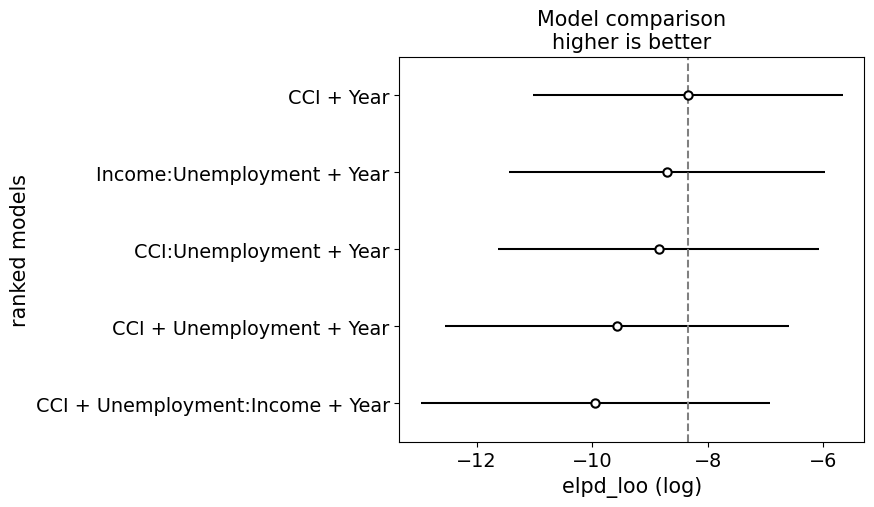

In [47]:
az.plot_compare(cmp_df_c)

## Compare Part C with Part A




In [45]:
print("Model comparison for Part B:")
display(cmp_df_1)

print("\nModel comparison for Part C:")
display(cmp_df_c)

Model comparison for Part B:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Unemployment:Income + Year,0,-10.811901,3.764312,0.000000,5.955594e-01,1.478973,0.000000,False,log
CCI + Unemployment + Year,1,-10.840474,3.742743,0.028573,4.044406e-01,1.269670,0.557993,False,log
CCI + Unemployment + Year + CCI:Unemployment,2,-11.049770,3.927931,0.237869,4.406002e-14,1.267783,0.569695,False,log
CCI:Unemployment + Year,3,-11.888959,3.578035,1.077058,0.000000e+00,1.699878,1.179122,False,log
Income:Unemployment + Year,4,-11.941588,3.578407,1.129687,0.000000e+00,1.729516,1.133753,False,log
CCI + Unemployment + Income + Year,5,-12.085460,4.807233,1.273559,1.315341e-15,1.481519,0.741167,False,log
Unemployment + Year,6,-12.086390,3.654621,1.274489,0.000000e+00,1.691137,1.159567,False,log
CCI,7,-12.321076,3.311110,1.509176,0.000000e+00,2.033434,1.391763,False,log
Income + Year,8,-12.547575,3.703666,1.735674,0.000000e+00,2.011158,1.412916,False,log
Income + Unemployment + Year,9,-12.600275,4.216885,1.788374,6.507637e-16,1.616913,0.660401,False,log



Model comparison for Part C:


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
CCI + Year,0,-8.341386,3.735832,0.000000,1.000000e+00,2.684723,0.000000,False,log
Income:Unemployment + Year,1,-8.705151,3.896568,0.363765,2.220446e-16,2.740415,0.486909,False,log
CCI:Unemployment + Year,2,-8.852194,4.079021,0.510808,1.023197e-15,2.780205,0.408863,False,log
CCI + Unemployment + Year,3,-9.576987,4.922088,1.235601,2.254003e-15,2.975561,0.414388,False,log
CCI + Unemployment:Income + Year,4,-9.947683,4.971387,1.606297,2.997602e-15,3.021992,0.559778,True,log


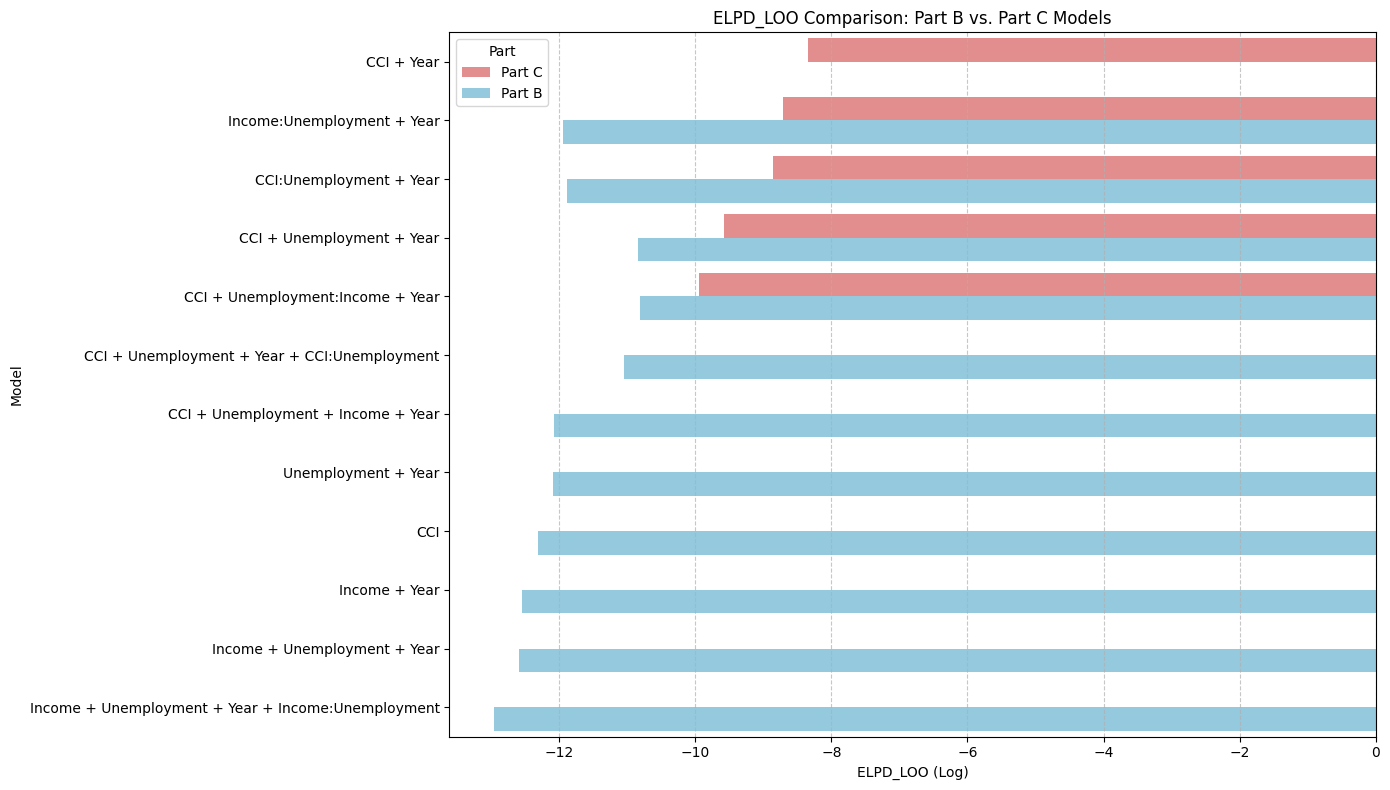

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract elpd_loo and model names from cmp_df_1 (Part B)
df_b_plot = cmp_df_1[['elpd_loo']].reset_index()
df_b_plot.rename(columns={'index': 'Model'}, inplace=True)
df_b_plot['Part'] = 'Part B'

# Extract elpd_loo and model names from cmp_df_c (Part C)
df_c_plot = cmp_df_c[['elpd_loo']].reset_index()
df_c_plot.rename(columns={'index': 'Model'}, inplace=True)
df_c_plot['Part'] = 'Part C'

# Concatenate the DataFrames
combined_elpd_loo = pd.concat([df_b_plot, df_c_plot])

# Create the plot
plt.figure(figsize=(14, 8))
sns.barplot(data=combined_elpd_loo.sort_values(by='elpd_loo', ascending=False),
            x='elpd_loo',
            y='Model',
            hue='Part',
            palette={'Part B': 'skyblue', 'Part C': 'lightcoral'},
            dodge=True)
plt.xlabel('ELPD_LOO (Log)')
plt.ylabel('Model')
plt.title('ELPD_LOO Comparison: Part B vs. Part C Models')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()